In [1]:
import shap
import pandas as pd
from pathlib import Path

# Re-fit the best German Credit configuration from Step 4: Stacked + SMOTE
# (SHAP needs a fitted model to explain, so we refit here for a clean run)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import re

SCALED_DIR = Path("../Data/Processed")
RANDOM_SEED = 42

def clean_column_names(df):
    df = df.copy()
    df.columns = [re.sub(r"[\[\]<>]", "_", str(col)) for col in df.columns]
    return df

X_german_train = clean_column_names(pd.read_csv(SCALED_DIR / "german_X_train.csv"))
X_german_test = clean_column_names(pd.read_csv(SCALED_DIR / "german_X_test.csv"))
y_german_train = pd.read_csv(SCALED_DIR / "german_y_train.csv").squeeze()
y_german_test = pd.read_csv(SCALED_DIR / "german_y_test.csv").squeeze()

# For SHAP, we'll explain XGBoost specifically (TreeExplainer needs a tree model,
# not the full stack) - XGBoost alone was close to the stack's performance and
# is directly explainable, whereas explaining a stacked ensemble's meta-learner
# is more complex and less standard practice
xgb_smote_german = ImbPipeline([
    ("smote", SMOTE(random_state=RANDOM_SEED)),
    ("clf", XGBClassifier(random_state=RANDOM_SEED, eval_metric="logloss"))
])
xgb_smote_german.fit(X_german_train, y_german_train)

# Extract just the fitted XGBoost model from the pipeline for SHAP
xgb_model_german = xgb_smote_german.named_steps["clf"]

explainer_german = shap.TreeExplainer(xgb_model_german)
shap_values_german = explainer_german.shap_values(X_german_test)

print("SHAP values shape:", shap_values_german.shape)

c:\Users\Thokozani\Desktop\BcomHons\Second Semester\Information Systems Research\Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP values shape: (200, 40)


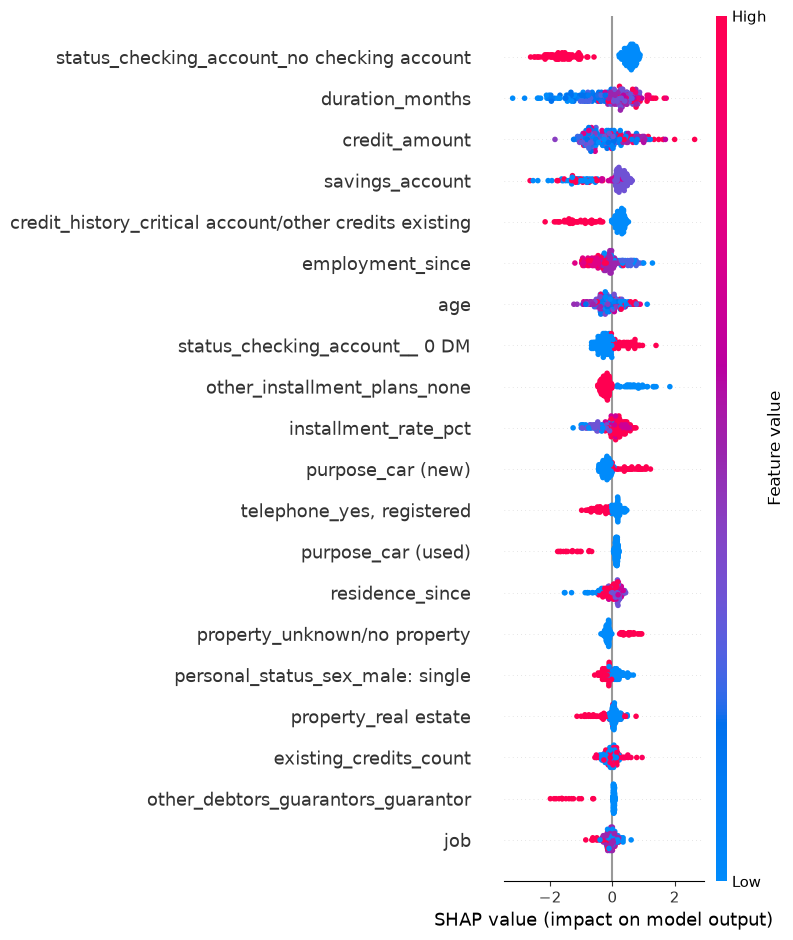

In [2]:
import matplotlib.pyplot as plt

# Global SHAP summary - shows which features matter most overall,
# and whether high/low values push toward default or non-default
shap.summary_plot(shap_values_german, X_german_test, show=False)
plt.tight_layout()
plt.savefig("../logs/shap_german_summary.png", dpi=150, bbox_inches="tight")
plt.show()

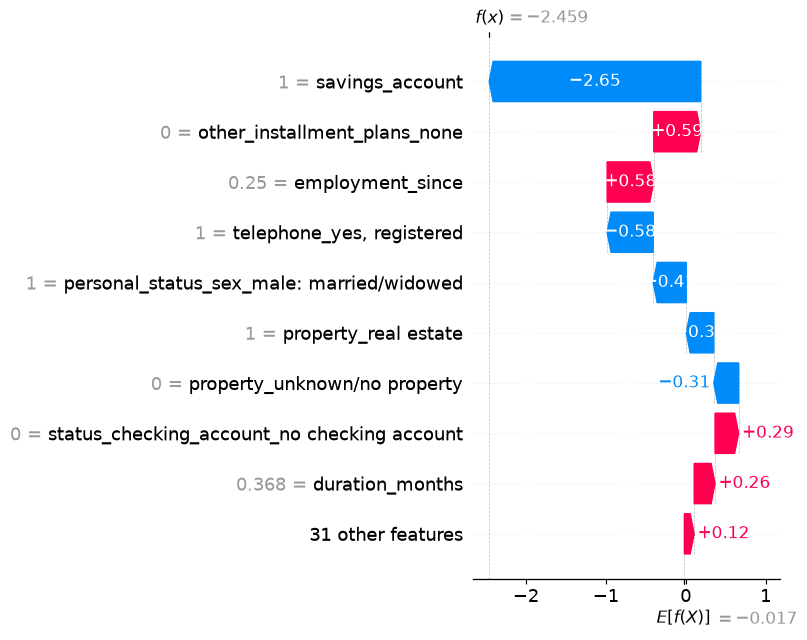

In [3]:
# Explain one specific prediction in detail - useful for showing HOW the
# model reached a decision for an individual applicant, not just overall patterns
explanation_single = shap.Explanation(
    values=shap_values_german[0],
    base_values=explainer_german.expected_value,
    data=X_german_test.iloc[0],
    feature_names=X_german_test.columns.tolist()
)
shap.waterfall_plot(explanation_single, show=False)
plt.tight_layout()
plt.savefig("../logs/shap_german_waterfall_row0.png", dpi=150, bbox_inches="tight")
plt.show()

In [4]:
from scipy.stats import spearmanr

# Fit XGBoost WITHOUT SMOTE for comparison
xgb_no_smote_german = XGBClassifier(random_state=RANDOM_SEED, eval_metric="logloss")
xgb_no_smote_german.fit(X_german_train, y_german_train)

explainer_no_smote = shap.TreeExplainer(xgb_no_smote_german)
shap_values_no_smote = explainer_no_smote.shap_values(X_german_test)

# Compare feature importance RANKINGS (mean absolute SHAP value per feature)
# between the SMOTE and no-SMOTE models - this is the actual RQ4 test
importance_smote = pd.Series(
    abs(shap_values_german).mean(axis=0), index=X_german_test.columns
).sort_values(ascending=False)

importance_no_smote = pd.Series(
    abs(shap_values_no_smote).mean(axis=0), index=X_german_test.columns
).sort_values(ascending=False)

# Spearman rank correlation - the actual stability metric your proposal committed to
rank_correlation, p_value = spearmanr(
    importance_smote.rank(), importance_no_smote.reindex(importance_smote.index).rank()
)

print(f"Spearman rank correlation (SMOTE vs no-SMOTE feature importance): {rank_correlation:.4f}")
print(f"p-value: {p_value:.4f}")

print("\nTop 10 features - WITH SMOTE:")
print(importance_smote.head(10))
print("\nTop 10 features - WITHOUT SMOTE:")
print(importance_no_smote.head(10))

Spearman rank correlation (SMOTE vs no-SMOTE feature importance): 0.9831
p-value: 0.0000

Top 10 features - WITH SMOTE:
status_checking_account_no checking account               1.001780
duration_months                                           0.725008
credit_amount                                             0.567330
savings_account                                           0.533152
credit_history_critical account/other credits existing    0.483583
employment_since                                          0.400340
age                                                       0.327899
status_checking_account__ 0 DM                            0.320943
other_installment_plans_none                              0.318017
installment_rate_pct                                      0.312440
dtype: float32

Top 10 features - WITHOUT SMOTE:
status_checking_account_no checking account               0.906250
credit_amount                                             0.741986
duration_months            

In [5]:
X_home_train = clean_column_names(pd.read_csv(SCALED_DIR / "home_X_train.csv"))
X_home_test = clean_column_names(pd.read_csv(SCALED_DIR / "home_X_test.csv"))
y_home_train = pd.read_csv(SCALED_DIR / "home_y_train.csv").squeeze()
y_home_test = pd.read_csv(SCALED_DIR / "home_y_test.csv").squeeze()

X_lending_train = clean_column_names(pd.read_csv(SCALED_DIR / "lending_X_train.csv"))
X_lending_test = clean_column_names(pd.read_csv(SCALED_DIR / "lending_X_test.csv"))
y_lending_train = pd.read_csv(SCALED_DIR / "lending_y_train.csv").squeeze()
y_lending_test = pd.read_csv(SCALED_DIR / "lending_y_test.csv").squeeze()

print(X_home_train.shape, X_lending_train.shape)

MemoryError: Unable to allocate 188. MiB for an array with shape (100, 246005) and data type float64

In [1]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import spearmanr
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import re

SCALED_DIR = Path("../Data/Processed")
RANDOM_SEED = 42

def clean_column_names(df):
    df.columns = [re.sub(r"[\[\]<>]", "_", str(col)) for col in df.columns]
    return df  # removed the .copy() - not needed here and was adding memory overhead

c:\Users\Thokozani\Desktop\BcomHons\Second Semester\Information Systems Research\Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
X_home_train = pd.read_csv(SCALED_DIR / "home_X_train.csv")
clean_column_names(X_home_train)  # modifies in place now, no copy needed

X_home_test = pd.read_csv(SCALED_DIR / "home_X_test.csv")
clean_column_names(X_home_test)

y_home_train = pd.read_csv(SCALED_DIR / "home_y_train.csv").squeeze()
y_home_test = pd.read_csv(SCALED_DIR / "home_y_test.csv").squeeze()

print(X_home_train.shape, X_home_test.shape)

(246005, 100) (61502, 100)


In [1]:
# ============================================================
# DATASET: LendingClub
# Purpose: SHAP stability check (RQ4) - with vs without SMOTE
# ============================================================

import pandas as pd
import numpy as np
import shap
from pathlib import Path
from scipy.stats import spearmanr
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import re

SCALED_DIR = Path("../Data/Processed")
RANDOM_SEED = 42

def clean_column_names(df):
    # XGBoost rejects feature names containing [, ], or < characters
    df.columns = [re.sub(r"[\[\]<>]", "_", str(col)) for col in df.columns]
    return df

# --- LendingClub data ---
X_lending_train = pd.read_csv(SCALED_DIR / "lending_X_train.csv")
clean_column_names(X_lending_train)

X_lending_test = pd.read_csv(SCALED_DIR / "lending_X_test.csv")
clean_column_names(X_lending_test)

y_lending_train = pd.read_csv(SCALED_DIR / "lending_y_train.csv").squeeze()
y_lending_test = pd.read_csv(SCALED_DIR / "lending_y_test.csv").squeeze()

print(X_lending_train.shape, X_lending_test.shape)

c:\Users\Thokozani\Desktop\BcomHons\Second Semester\Information Systems Research\Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(8000, 69) (2000, 69)


In [4]:
# ============================================================
# DATASET: LendingClub
# Step: fit XGBoost with and without SMOTE
# ============================================================

# Plain XGBoost - no resampling applied
xgb_no_smote_lending = XGBClassifier(random_state=RANDOM_SEED, eval_metric="logloss")
xgb_no_smote_lending.fit(X_lending_train, y_lending_train)

# XGBoost with SMOTE applied only to training data (via imblearn Pipeline,
# so resampling never touches the test set)
xgb_smote_lending = ImbPipeline([
    ("smote", SMOTE(random_state=RANDOM_SEED)),
    ("clf", XGBClassifier(random_state=RANDOM_SEED, eval_metric="logloss"))
])
xgb_smote_lending.fit(X_lending_train, y_lending_train)

# Extract just the fitted XGBoost model out of the pipeline - SHAP needs
# the raw model, not the pipeline wrapper
xgb_model_lending_smote = xgb_smote_lending.named_steps["clf"]

print("Both LendingClub models fitted")

Both LendingClub models fitted


In [5]:
# ============================================================
# DATASET: LendingClub
# Step: SHAP values + Spearman stability comparison (RQ4)
# ============================================================

# Generate SHAP values for the no-SMOTE model
explainer_lending_no_smote = shap.TreeExplainer(xgb_no_smote_lending)
shap_lending_no_smote = explainer_lending_no_smote.shap_values(X_lending_test)

# Generate SHAP values for the SMOTE model
explainer_lending_smote = shap.TreeExplainer(xgb_model_lending_smote)
shap_lending_smote = explainer_lending_smote.shap_values(X_lending_test)

# Reduce each feature's SHAP values to one overall importance score
# (mean absolute SHAP value across all test rows), then rank features
importance_lending_no_smote = pd.Series(
    abs(shap_lending_no_smote).mean(axis=0), index=X_lending_test.columns
).sort_values(ascending=False)

importance_lending_smote = pd.Series(
    abs(shap_lending_smote).mean(axis=0), index=X_lending_test.columns
).sort_values(ascending=False)

# Spearman rank correlation between the two importance rankings -
# this is the actual RQ4 stability metric committed to in the approved plan
rank_corr_lending, p_lending = spearmanr(
    importance_lending_smote.rank(),
    importance_lending_no_smote.reindex(importance_lending_smote.index).rank()
)

print(f"LendingClub - Spearman correlation (SMOTE vs no-SMOTE): {rank_corr_lending:.4f}, p={p_lending:.4f}")
print("\nTop 10 - WITH SMOTE:\n", importance_lending_smote.head(10))
print("\nTop 10 - WITHOUT SMOTE:\n", importance_lending_no_smote.head(10))

LendingClub - Spearman correlation (SMOTE vs no-SMOTE): 0.7966, p=0.0000

Top 10 - WITH SMOTE:
 paid_total              1.284535
installment             1.218794
paid_principal          1.129023
grade                   1.054191
issue_month_Mar-2018    0.911344
issue_month_Jan-2018    0.871193
balance                 0.556214
inquiries_last_12m      0.527224
paid_interest           0.398925
loan_amount             0.368723
dtype: float32

Top 10 - WITHOUT SMOTE:
 installment                         1.636595
paid_total                          1.230633
paid_principal                      0.943558
issue_month_Mar-2018                0.897824
issue_month_Jan-2018                0.886227
interest_rate                       0.781618
paid_interest                       0.689344
balance                             0.535029
annual_income                       0.336381
months_since_last_credit_inquiry    0.286981
dtype: float32


In [1]:
# ============================================================
# DATASET: Home Credit
# Purpose: SHAP stability check (RQ4) - attempt 2, more memory-careful
# ============================================================

import pandas as pd
import numpy as np
import shap
import gc
from pathlib import Path
from scipy.stats import spearmanr
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import re

SCALED_DIR = Path("../Data/Processed")
RANDOM_SEED = 42

def clean_column_names(df):
    df.columns = [re.sub(r"[\[\]<>]", "_", str(col)) for col in df.columns]
    return df

X_home_train = pd.read_csv(SCALED_DIR / "home_X_train.csv")
clean_column_names(X_home_train)

X_home_test = pd.read_csv(SCALED_DIR / "home_X_test.csv")
clean_column_names(X_home_test)

y_home_train = pd.read_csv(SCALED_DIR / "home_y_train.csv").squeeze()
y_home_test = pd.read_csv(SCALED_DIR / "home_y_test.csv").squeeze()

print(X_home_train.shape, X_home_test.shape)

c:\Users\Thokozani\Desktop\BcomHons\Second Semester\Information Systems Research\Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(246005, 100) (61502, 100)


In [2]:
# ============================================================
# DATASET: Home Credit - NO SMOTE only (do SMOTE separately after)
# ============================================================

# Use a smaller sample for SHAP evaluation - 300 rows instead of 1000,
# to reduce memory pressure further
X_home_test_sample = X_home_test.sample(n=300, random_state=RANDOM_SEED)

xgb_no_smote_home = XGBClassifier(random_state=RANDOM_SEED, eval_metric="logloss")
xgb_no_smote_home.fit(X_home_train, y_home_train)

explainer_home_no_smote = shap.TreeExplainer(xgb_no_smote_home)
shap_home_no_smote = explainer_home_no_smote.shap_values(X_home_test_sample)

# Save just the small importance ranking (a Series, tiny memory footprint) -
# this is all we actually need going forward
importance_home_no_smote = pd.Series(
    abs(shap_home_no_smote).mean(axis=0), index=X_home_test_sample.columns
).sort_values(ascending=False)

# Now free the large objects - model, explainer, and raw SHAP array -
# before starting the SMOTE model, since we don't need them anymore
del xgb_no_smote_home, explainer_home_no_smote, shap_home_no_smote
gc.collect()

print("No-SMOTE done and memory freed")
print(importance_home_no_smote.head(10))

No-SMOTE done and memory freed
EXT_SOURCE_3       0.400159
EXT_SOURCE_2       0.361962
AMT_GOODS_PRICE    0.308788
AMT_CREDIT         0.280216
CODE_GENDER_M      0.165994
DAYS_BIRTH         0.121107
DAYS_EMPLOYED      0.118629
AMT_ANNUITY        0.117743
DAYS_ID_PUBLISH    0.091560
FLAG_OWN_CAR       0.086224
dtype: float32


In [3]:
# ============================================================
# DATASET: Home Credit - WITH SMOTE
# ============================================================

# XGBoost with SMOTE applied only to training data (via imblearn Pipeline,
# so resampling never touches the test set)
xgb_smote_home = ImbPipeline([
    ("smote", SMOTE(random_state=RANDOM_SEED)),
    ("clf", XGBClassifier(random_state=RANDOM_SEED, eval_metric="logloss"))
])
xgb_smote_home.fit(X_home_train, y_home_train)

# Extract just the fitted XGBoost model out of the pipeline - SHAP needs
# the raw model, not the pipeline wrapper
xgb_model_home_smote = xgb_smote_home.named_steps["clf"]

# Generate SHAP values on the same 300-row sample used for the no-SMOTE model,
# so both rankings are computed on identical test rows
explainer_home_smote = shap.TreeExplainer(xgb_model_home_smote)
shap_home_smote = explainer_home_smote.shap_values(X_home_test_sample)

# Reduce to one importance score per feature (mean absolute SHAP value),
# same approach as the no-SMOTE version, so the two are directly comparable
importance_home_smote = pd.Series(
    abs(shap_home_smote).mean(axis=0), index=X_home_test_sample.columns
).sort_values(ascending=False)

# Free the large objects (model, explainer, raw SHAP array) now that we
# only need the small importance ranking going forward - same memory
# discipline that let the no-SMOTE step succeed
del xgb_smote_home, xgb_model_home_smote, explainer_home_smote, shap_home_smote
gc.collect()

print("SMOTE done and memory freed")
print(importance_home_smote.head(10))

SMOTE done and memory freed
AMT_REQ_CREDIT_BUREAU_YEAR    0.503389
EXT_SOURCE_3                  0.453048
OBS_30_CNT_SOCIAL_CIRCLE      0.401591
EXT_SOURCE_2                  0.384659
HOUR_APPR_PROCESS_START       0.341739
CNT_CHILDREN                  0.270993
AMT_GOODS_PRICE               0.270625
AMT_CREDIT                    0.241507
CODE_GENDER_M                 0.156492
DAYS_BIRTH                    0.120791
dtype: float32


In [4]:
# ============================================================
# DATASET: Home Credit - Spearman stability comparison (RQ4)
# ============================================================

# Spearman rank correlation between the two importance rankings -
# the actual RQ4 stability metric committed to in the approved plan.
# reindex() aligns the no-SMOTE ranking to the SMOTE ranking's feature order
# before comparing ranks, so we're comparing the same features against each other
rank_corr_home, p_home = spearmanr(
    importance_home_smote.rank(),
    importance_home_no_smote.reindex(importance_home_smote.index).rank()
)

print(f"Home Credit - Spearman correlation (SMOTE vs no-SMOTE): {rank_corr_home:.4f}, p={p_home:.4f}")

Home Credit - Spearman correlation (SMOTE vs no-SMOTE): 0.9060, p=0.0000
